<a href="https://colab.research.google.com/github/Chetankamineni/Music-popularity-prediction/blob/main/spotify_pop_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Step 1: Install Required Libraries

In [ ]:
!pip install kagglehub pandas scikit-learn matplotlib seaborn --quiet

**📝 Docs:**
We install the libraries needed for:

**kagglehub:** to download Kaggle datasets directly into Colab

**pandas:** for data handling

**scikit-learn:** for ML tasks

**matplotlib & seaborn:** for plotting and visualization

✅ Step 2: Authenticate with Kaggle API

In [ ]:
from google.colab import files
files.upload()  # upload your kaggle.json file


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"chetankamineni","key":"e10f16f0a2595cb901083c049f4e2319"}'}

In [ ]:
import os, shutil
os.makedirs("/root/.kaggle", exist_ok=True)
shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 600)

📝 Docs:
To use Kaggle's API (required by kagglehub), you need a kaggle.json file with your API credentials.
This block:

Uploads the file

Moves it to the right folder (/root/.kaggle/)

Sets the permissions so Kaggle API can use it securely

✅ Step 3: Download Dataset with KaggleHub

In [ ]:
import kagglehub

# Download the dataset
path = kagglehub.dataset_download("devdope/200k-spotify-songs-light-dataset")
print("✅ Dataset downloaded to:", path)

✅ Dataset downloaded to: /kaggle/input/200k-spotify-songs-light-dataset


📝 Docs:
This uses kagglehub to download the 200k Spotify Songs Light Dataset from Kaggle.
It stores the dataset in Colab’s local environment and returns the full path to the dataset folder.

✅ Step 4: Load the Data

In [ ]:
import pandas as pd
import os

# Show all files in the downloaded folder
print("📁 Files in dataset folder:")
print(os.listdir(path))

# Load CSV file
csv_path = os.path.join(path, "light_spotify_dataset.csv")
df = pd.read_csv(csv_path)

# Preview the data
df.head()

📁 Files in dataset folder:
['light_spotify_dataset.json', 'light_spotify_dataset.csv']


,artist,song,emotion,variance,Genre,Release Date,Key,Tempo,Loudness,Explicit,Popularity,Energy,Danceability,Positiveness,Speechiness,Liveness,Acousticness,Instrumentalness
0,ABBA,She's My Kind Of Girl,joy,0.447619,pop,2014,F Maj,128,-6.00,No,31,78,56,60,3,31,7,0
1,ABBA,"Andante, Andante",love,0.202222,pop,1980,A# Maj,102,-10.72,No,59,36,52,38,2,7,68,0
2,ABBA,As Good As New,sadness,0.300881,pop,1979,E Maj,139,-5.70,No,50,78,85,97,3,8,20,2
3,ABBA,Bang,joy,0.355000,pop,1975,F Maj,132,-3.00,No,52,76,50,89,3,32,3,0
4,ABBA,Bang-A-Boomerang,joy,0.355000,pop,1975,F Maj,132,-3.00,No,52,76,50,89,3,32,3,0


📝 Docs:
We:

List all files in the dataset directory to find the CSV

Load the CSV using pandas

Preview the first few rows of the dataset

✅ Step 5: Basic Preprocessing

In [ ]:
print(df.columns)
# Drop missing values
df = df.dropna()

# Create a binary column: is the song popular (Popularity >= 70)?
df['is_popular'] = df['Popularity'] >= 70



Index(['artist', 'song', 'emotion', 'variance', 'Genre', 'Release Date', 'Key',
       'Tempo', 'Loudness', 'Explicit', 'Popularity', 'Energy', 'Danceability',
       'Positiveness', 'Speechiness', 'Liveness', 'Acousticness',
       'Instrumentalness'],
      dtype='object')


📝 Docs:
To clean and prepare the data:

Drop any rows with missing values (you could use imputation instead)

Create a new target column is_popular, where songs with popularity ≥ 70 are labeled as True (popular)



✅ Step 6: Select Features & Labels

In [ ]:
features = ['Danceability', 'Energy', 'Loudness', 'Speechiness',
            'Acousticness', 'Instrumentalness', 'Liveness', 'Positiveness', 'Tempo']


X = df[features]  # input features
y = df['is_popular'].astype(int)  # binary target (0 or 1)

📝 Docs:
We're using common Spotify audio features as inputs (X).
The target (y) is whether the song is considered popular or not.

✅ Step 7: Split & Normalize Data

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


📝 Docs:

We split the dataset into 80% training and 20% test.

Then, we scale the features to have zero mean and unit variance using StandardScaler — good practice for ML models like Random Forest.

✅ Step 8: Train the Model

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

📝 Docs:
We train a Random Forest Classifier with 100 trees.
It’s good for tabular data and handles both numeric and categorical features.

✅ Step 9: Evaluate the Model

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     44031
           1       0.98      0.82      0.89      3365

    accuracy                           0.99     47396
   macro avg       0.98      0.91      0.94     47396
weighted avg       0.99      0.99      0.99     47396



/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127911 (\N{HEADPHONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


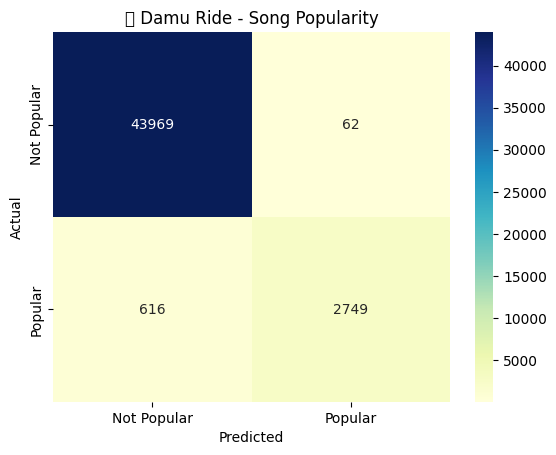

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions
y_pred = model.predict(X_test)

# Report
print("📊 Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu", xticklabels=["Not Popular", "Popular"], yticklabels=["Not Popular", "Popular"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("🎧 Damu Ride - Song Popularity")
plt.show()


📝 Docs:
We evaluate the model using:

A classification report (precision, recall, F1-score)

A confusion matrix heatmap for visualizing prediction performance

In [ ]:
# Filter the dataset to find not so popular songs
popular_songs = df[df['Popularity'] > 60]

# Get a random song from the filtered dataset
random_popular_song = popular_songs.sample(1)

# Display the song's details
print(random_not_popular_song[['song', 'artist', 'Popularity']])


             song               artist  Popularity
199604  Damu Ride  Damu Ridas (Bloods)          21
